# Система прогнозирования продаж для «Прилавка»

## Описание задачи

Ваш клиент — компания «Прилавок», новая сеть дарксторов в России, специализирующаяся на быстрой доставке продуктов и товаров повседневного спроса. Компания работает с 2023 года и управляет более чем 45 дарксторами.

**Бизнес-проблема**

Эффективность дарксторов критически зависит от точности управления запасами. Текущая система планирования закупок работает на субъективных оценках аналитиков, что приводит к разным проблемам:
- К дефициту товаров в пиковые периоды (недополучение 3–5% выручки).
- К избыточным запасам и списаниям продуктов с коротким сроком годности (2–3% от выручки).
- К неэффективному использованию времени аналитиков (15–20 часов в неделю на ручное планирование).

**Цель проекта**

Разработать автоматизированную систему прогнозирования недельных продаж для каждого отдела во всех дарксторах с использованием машинного обучения (модель CatBoost). Система будет работать в режиме пакетного внедрения с недельным циклом: модель будет переобучаться каждое воскресенье вечером, а к понедельнику утром прогнозы будут готовы для передачи в систему планирования закупок.

## Описание данных

Для работы доступны исторические данные о продажах за февраль 2023 — октябрь 2025, организованные в виде нескольких таблиц в PostgreSQL:

1. Таблица `sales` — исторические данные о продажах:
   - `Store` — номер даркстора (1–45).
   - `Dept` — номер отдела внутри даркстора (1–99).
   - `Date` — неделя (дата начала недели).
   - `Weekly_Sales` — недельные продажи (руб., целевая переменная).
   - `IsHoliday` — признак праздничной недели.

2. Таблица `stores` — информация о дарксторах:
   - `Store` — номер даркстора.
   - `Type` — тип даркстора (A, B, C).
   - `Size` — размер даркстора в условных единицах.

3. Таблица `features` — внешние факторы:
   - `Store`, `Date` — идентификаторы.
   - `Temperature` — средняя температура за неделю.
   - `Fuel_Price` — средняя цена бензина.
   - `MarkDown1-5` — факторы рекламных акций и скидок.
   - `CPI` — индекс потребительских цен.
   - `Unemployment` — уровень безработицы.

4. Таблица `plan` — данные для инференса (ноябрь 2025 — июль 2026), содержит те же столбцы, что и `sales`, кроме `Weekly_Sales`.

## План работы

Проект состоит из двух частей. В этом ноутбуке вы выполните первую:

1. Первичный анализ и очистка данных.
2. Предобработка и создание признаков.
3. Мониторинг стабильности признаков (PSI).
4. Обучение модели CatBoost и оценка качества.



In [1]:
%pip install -r requirements.txt -q


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Здесь все необходимые импорты

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import shap

import os
import sys

import psycopg2

import warnings
warnings.filterwarnings("ignore")

Фиксируем `random_state` для воспроизводимости результатов.

In [3]:
RANDOM_STATE = 1703

In [4]:
TARGET_COL = 'weekly_sales'

In [5]:
# Загрузка env переменных
from dotenv import load_dotenv

load_dotenv('.env')

True

### Шаг 1. Первичный анализ данных

**Задача:** подключитесь к базе данных PostgreSQL и загрузите данные для анализа.

**Важно:** не храните креды в коде! Используйте переменные окружения или Airflow Variables и Connections.

In [6]:
# Создание строки подключения
SQL_URL = connection_string = 'postgresql://{}:{}@{}:{}/{}?sslmode=require'.format(
    os.getenv('DB_USER'), os.getenv('DB_PASSWORD'), os.getenv('DB_HOST'), os.getenv('DB_PORT'), os.getenv('DB_NAME')
)

In [7]:
# Создание движка SQL для подключения к базе данных
from sqlalchemy import create_engine
sql_engine = create_engine(SQL_URL)

**Вывод по задаче**
Подключение к базе данных выполнено. Креды получены из переменных окружения

**Задача:** загрузите три таблицы из PostgreSQL: `sales`, `stores`, `features`.

Используйте SQL-запросы для загрузки данных через функцию `pd.read_sql_query()`.

In [8]:
# Загрузка данных из базы данных
dfs = {}
for table_name in ['sales', 'stores', 'features']:
    dfs[table_name] = pd.read_sql_query(f"SELECT * FROM {table_name}", sql_engine)

In [9]:
# Вывод первых строк таблиц
for name, df in dfs.items():
    display(f"Table: {name}")
    display(df.head())

'Table: sales'

,store,dept,date,weekly_sales,is_holiday
0,1,1,2023-02-05,24924.50,False
1,29,5,2023-02-05,15552.08,False
2,29,6,2023-02-05,3200.22,False
3,29,7,2023-02-05,10820.05,False
4,29,8,2023-02-05,20055.64,False


'Table: stores'

,store,type,size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


'Table: features'

,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,42.31,2.572,7028.8,NaN,NaN,NaN,NaN,211.096358,8.106
1,29,5,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
2,29,6,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
3,29,7,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064
4,29,8,2023-02-05,24.36,2.788,7028.8,NaN,NaN,NaN,NaN,131.527903,10.064


In [10]:
# Преобразование столбцов date в datetime
dfs['sales']['date'] = pd.to_datetime(dfs['sales']['date'])
dfs['features']['date'] = pd.to_datetime(dfs['features']['date'])

**Вывод по задаче**
Таблицы загружены с помощью SQL и сохранены в словарь `dfs` под отдельными ключами

**Задача:** обработайте пропуски и дубликаты в каждой таблице.

Перед обработкой изучите структуру пропусков и их причины.

In [11]:
# Проверка на пропуски и дубликаты
for name, df in dfs.items():
    display(f"Table: {name}")
    display('Nulls: ', df.isnull().sum())
    display('Duplicates: ', df.duplicated().sum())
    display('---')

'Table: sales'

'Nulls: '

store           0
dept            0
date            0
weekly_sales    0
is_holiday      0
dtype: int64

'Duplicates: '

np.int64(0)

...

'Nulls: '

store                0
dept                 0
date                 0
temperature          0
fuel_price           0
factor1              0
factor2         310322
factor3         284479
factor4         286603
factor5         270138
cpi                  0
unemployment         0
dtype: int64

'Duplicates: '

np.int64(0)

'---'

Столбцы factor1 — factor5 - это факторы рекламных акций и скидок, анонимизированные показатели. Factor2 - factor 5 содержат большое количество пропусков, так как акции проводятся не каждую неделю.

В других признаках пропусков не выявлено

Дублирования строк не выявлено

In [12]:
# Описание данных в столбцах factor2 — factor5
dfs['features'][['factor1', 'factor2', 'factor3', 'factor4', 'factor5']].describe().T

,count,mean,std,min,25%,50%,75%,max
factor1,421570.0,10337.221240,9502.153632,7028.80,7028.80,7028.80,9431.920624,103184.98
factor2,111248.0,3334.628621,9475.357325,-265.76,41.60,192.00,1926.940000,104519.54
factor3,137091.0,1439.421384,9623.078290,-29.10,5.08,24.60,103.990000,141630.61
factor4,134967.0,3383.168256,6292.384031,0.22,504.22,1481.31,3595.040000,67474.85
factor5,151432.0,4628.975079,5962.887455,135.16,1878.44,3359.45,5563.800000,108519.28


Пропуски заполним максимально возможным отрицательным числом. Далее CatBoost сможет отличить их от реальных значений

In [13]:
FACTOR_COLS = ['factor1', 'factor2', 'factor3', 'factor4', 'factor5']
FACTORS_FILL_VALUE = dfs['features'][FACTOR_COLS].min().min() - 1_000_000

dfs['features'][FACTOR_COLS] = dfs['features'][FACTOR_COLS].fillna(FACTORS_FILL_VALUE)

In [14]:
dfs['features'].isnull().sum()

store           0
dept            0
date            0
temperature     0
fuel_price      0
factor1         0
factor2         0
factor3         0
factor4         0
factor5         0
cpi             0
unemployment    0
dtype: int64

In [15]:
dfs['features'].head(1)

,store,dept,date,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,42.31,2.572,7028.8,-1000265.76,-1000265.76,-1000265.76,-1000265.76,211.096358,8.106


**Вывод по задаче**
Заполнены пропуски в таблице `features` в столбцах `factor*`. Для заполнение используется число сильно меньшее минимального значения этих признаков

**Задача:** визуализируйте распределение продаж по времени (по месяцам и неделям).

Цель: выявить визуально наличие сезонности в данных. Обратите внимание:
- На периодические всплески (праздники, выходные).
- На общий тренд (рост и спад продаж).
- На аномальные периоды.

In [16]:
# Копия таблицы sales
df = dfs['sales'].copy()


In [17]:
# Период продаж
df['date'].min(), df['date'].max()

(Timestamp('2023-02-05 00:00:00'), Timestamp('2025-10-26 00:00:00'))

In [18]:
# Суммарные продажи по месяцам и неделям
monthly_sales = (
    df.groupby(df['date'].dt.to_period('M'))['weekly_sales']
    .sum()
    .sort_index()
)
monthly_sales.index = monthly_sales.index.to_timestamp()

weekly_sales = df.groupby('date')['weekly_sales'].sum().sort_index()
holiday_weeks = df.loc[df['is_holiday'], 'date'].drop_duplicates().sort_values()

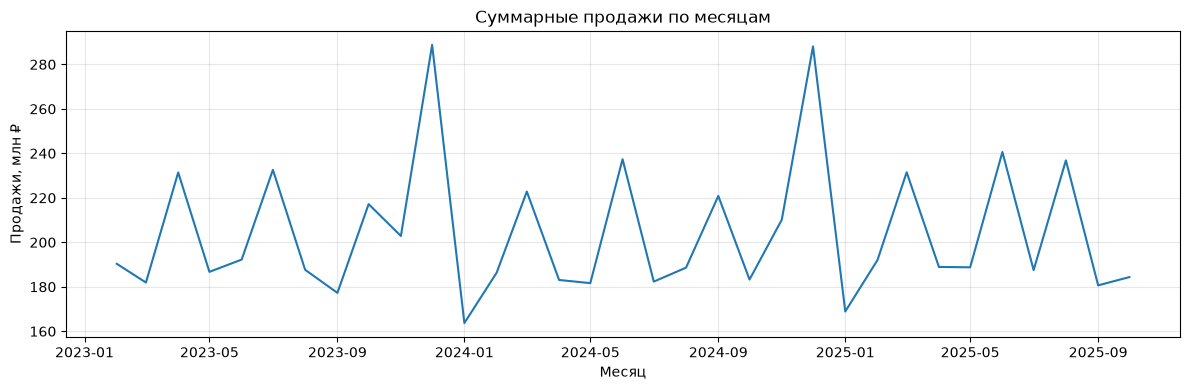

In [19]:
# Визуализация продаж по месяцам
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales.index, monthly_sales / 1e6)
plt.title('Суммарные продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Продажи, млн ₽')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

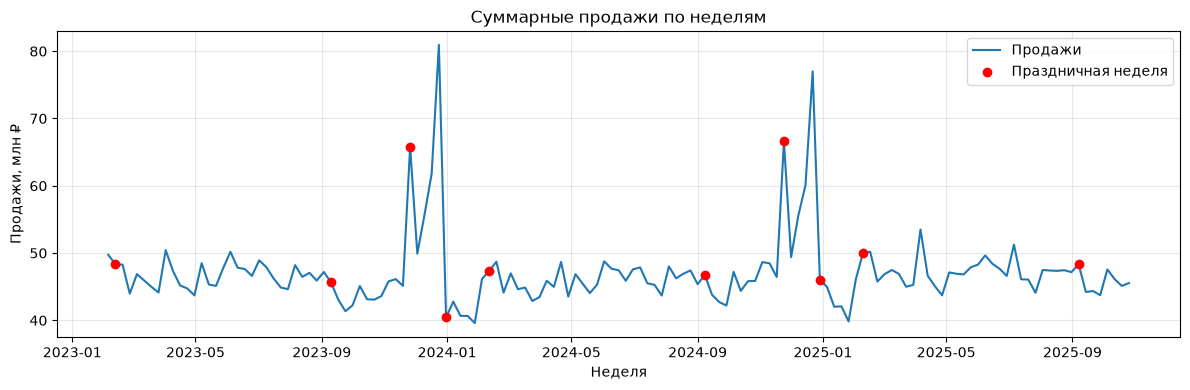

In [20]:
# Визуализация продаж по неделям
plt.figure(figsize=(12, 4))
plt.plot(weekly_sales.index, weekly_sales / 1e6, label='Продажи')
plt.scatter(
    holiday_weeks,
    weekly_sales.reindex(holiday_weeks) / 1e6,
    color='red',
    zorder=3,
    label='Праздничная неделя',
)
plt.title('Суммарные продажи по неделям')
plt.xlabel('Неделя')
plt.ylabel('Продажи, млн ₽')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Вывод по задаче**

Сезонность выраженная и повторяется каждый год: пик продаж приходится на декабрь (~280–290 млн ₽), а минимум — на январь (~165–170 млн ₽). Также заметны более слабые колебания весной, летом и в начале осени.

На недельном графике картина такая же: обычный уровень — около 42–50 млн ₽, а главные пики приходятся на конец 2023 и 2024 годов. При этом сам факт праздника не гарантирует рост продаж — сильнее всего влияет период перед Новым годом.

Явного тренда роста или падения за 2023–2025 годы нет. Повторяющиеся декабрьские пики и январские провалы — это сезонность, а не выбросы.

Для модели стоит использовать календарные признаки и учитывать не только наличие праздника, но и его тип и положение в году.

**Задача:** объедините три таблицы в одну для дальнейшего анализа.

Используйте операции `merge()` для соединения таблиц по общим ключам.

In [21]:
# Объединение таблиц
df = dfs['sales']
df = df.merge(dfs['stores'], on='store', how='left')
df = df.merge(dfs['features'], on=['store', 'dept', 'date'], how='left')
df.head()

,store,dept,date,weekly_sales,is_holiday,type,size,temperature,fuel_price,factor1,factor2,factor3,factor4,factor5,cpi,unemployment
0,1,1,2023-02-05,24924.50,False,A,151315,42.31,2.572,7028.8,-1000265.76,-1000265.76,-1000265.76,-1000265.76,211.096358,8.106
1,29,5,2023-02-05,15552.08,False,B,93638,24.36,2.788,7028.8,-1000265.76,-1000265.76,-1000265.76,-1000265.76,131.527903,10.064
2,29,6,2023-02-05,3200.22,False,B,93638,24.36,2.788,7028.8,-1000265.76,-1000265.76,-1000265.76,-1000265.76,131.527903,10.064
3,29,7,2023-02-05,10820.05,False,B,93638,24.36,2.788,7028.8,-1000265.76,-1000265.76,-1000265.76,-1000265.76,131.527903,10.064
4,29,8,2023-02-05,20055.64,False,B,93638,24.36,2.788,7028.8,-1000265.76,-1000265.76,-1000265.76,-1000265.76,131.527903,10.064


In [22]:
# Проверка на пропуски
assert df.isnull().sum().sum() == 0, 'Пропуски в объединенной таблице!'
assert df.duplicated().sum() == 0, 'Дубликаты в объединенной таблице!'

**Задача:** оцените корреляцию целевой переменной `Weekly_Sales` с другими признаками.

Ответьте на вопросы:
- Какие признаки сильнее всего коррелируют с продажами?
- Есть ли сильно коррелирующие между собой признаки (мультиколлинеарность)?

Посмотрим на линейные зависимости с помощью `.corr` и на нелинейные с помощью `.phik`

In [23]:
def heatmap(df, title=''):
    plt.figure(figsize=(20, 15))

    sns.heatmap(
        df,
        cmap="coolwarm",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.title(title, fontsize=16)
    plt.show()

In [24]:
# Функция для получения пар признаков со значением их корреляции
def phik_to_pairs(df_phik):
    s = df_phik.stack()
    s = s[s.index.get_level_values(0) != s.index.get_level_values(1)]
    s = s[s.index.get_level_values(0) < s.index.get_level_values(1)]
    s = s.sort_values(ascending=False)
    return s

In [25]:
# Подсчет линейных корреляций
df_corr = df.corr(numeric_only=True)

In [26]:
# Подсчет нелинейных корреляций
df_phik = df.phik_matrix(
    interval_cols=[
        'store',
        'dept_x',
        'weekly_sales',
        'size',
        'dept_y',
        'temperature',
        'fuel_price',
        'factor1',
        'factor2',
        'factor3',
        'factor4',
        'factor5',
        'cpi',
        'unemployment'
    ]
)

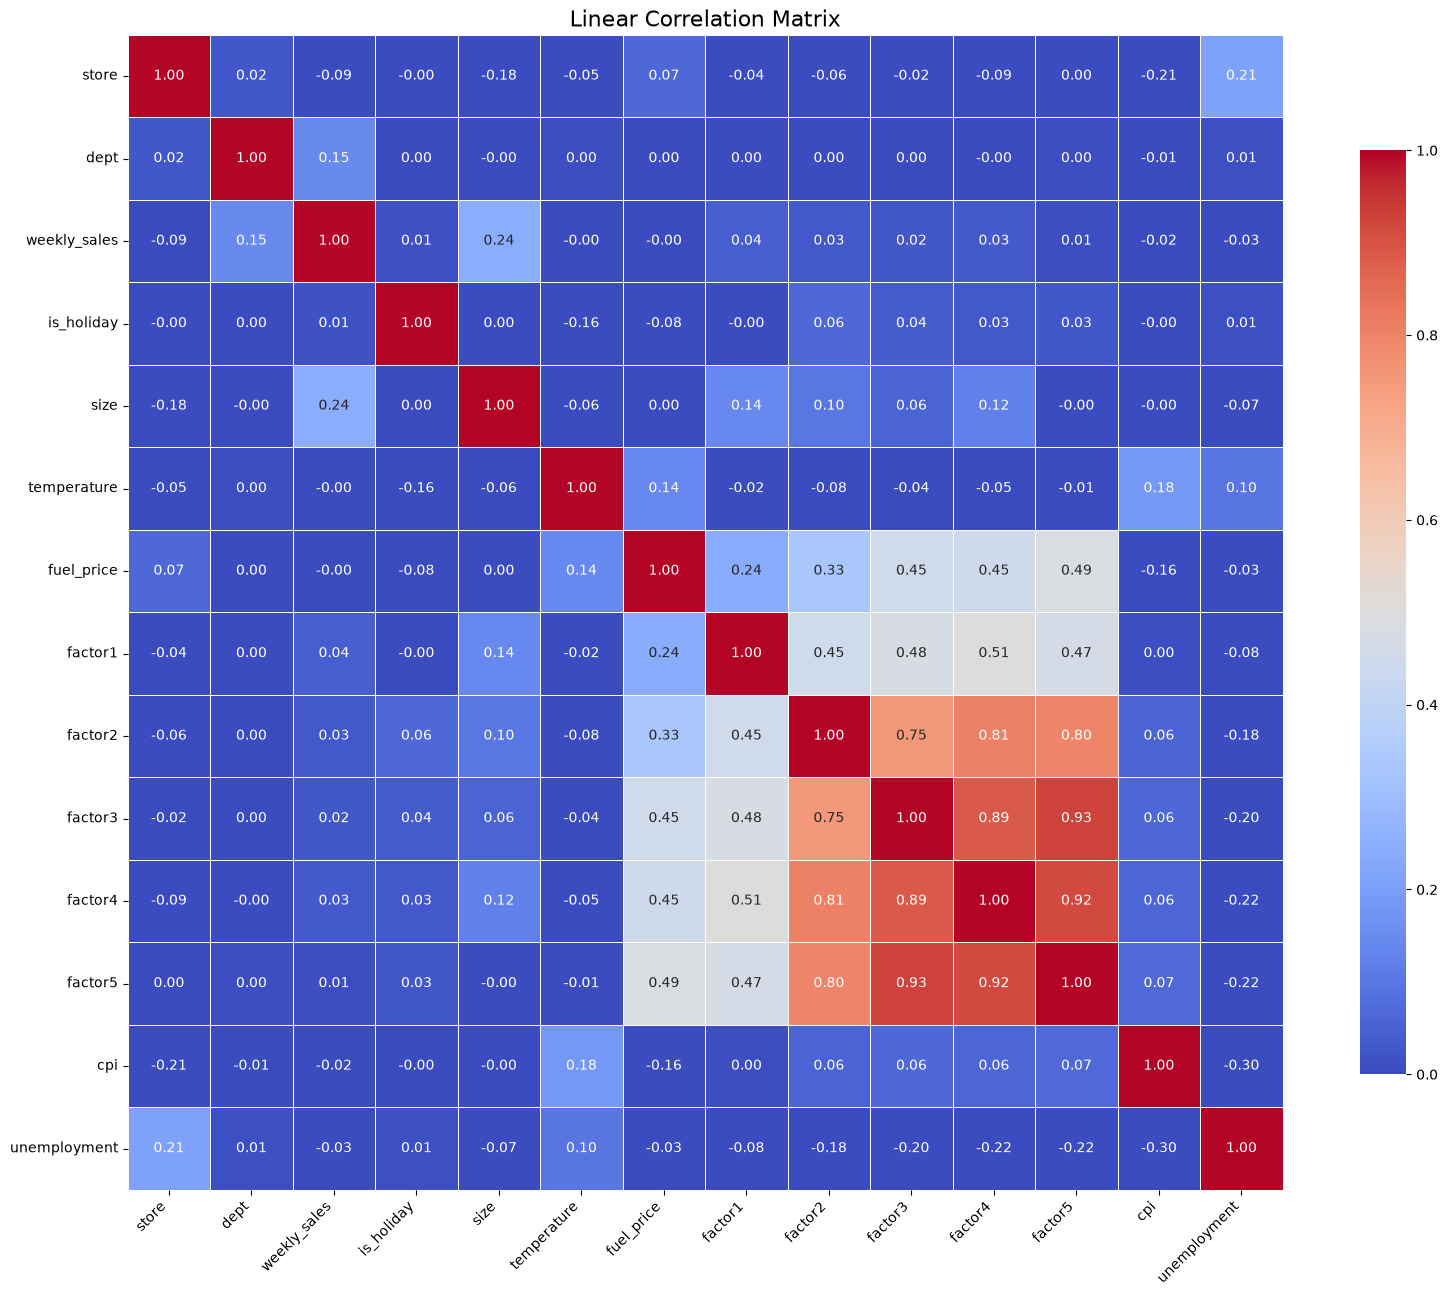

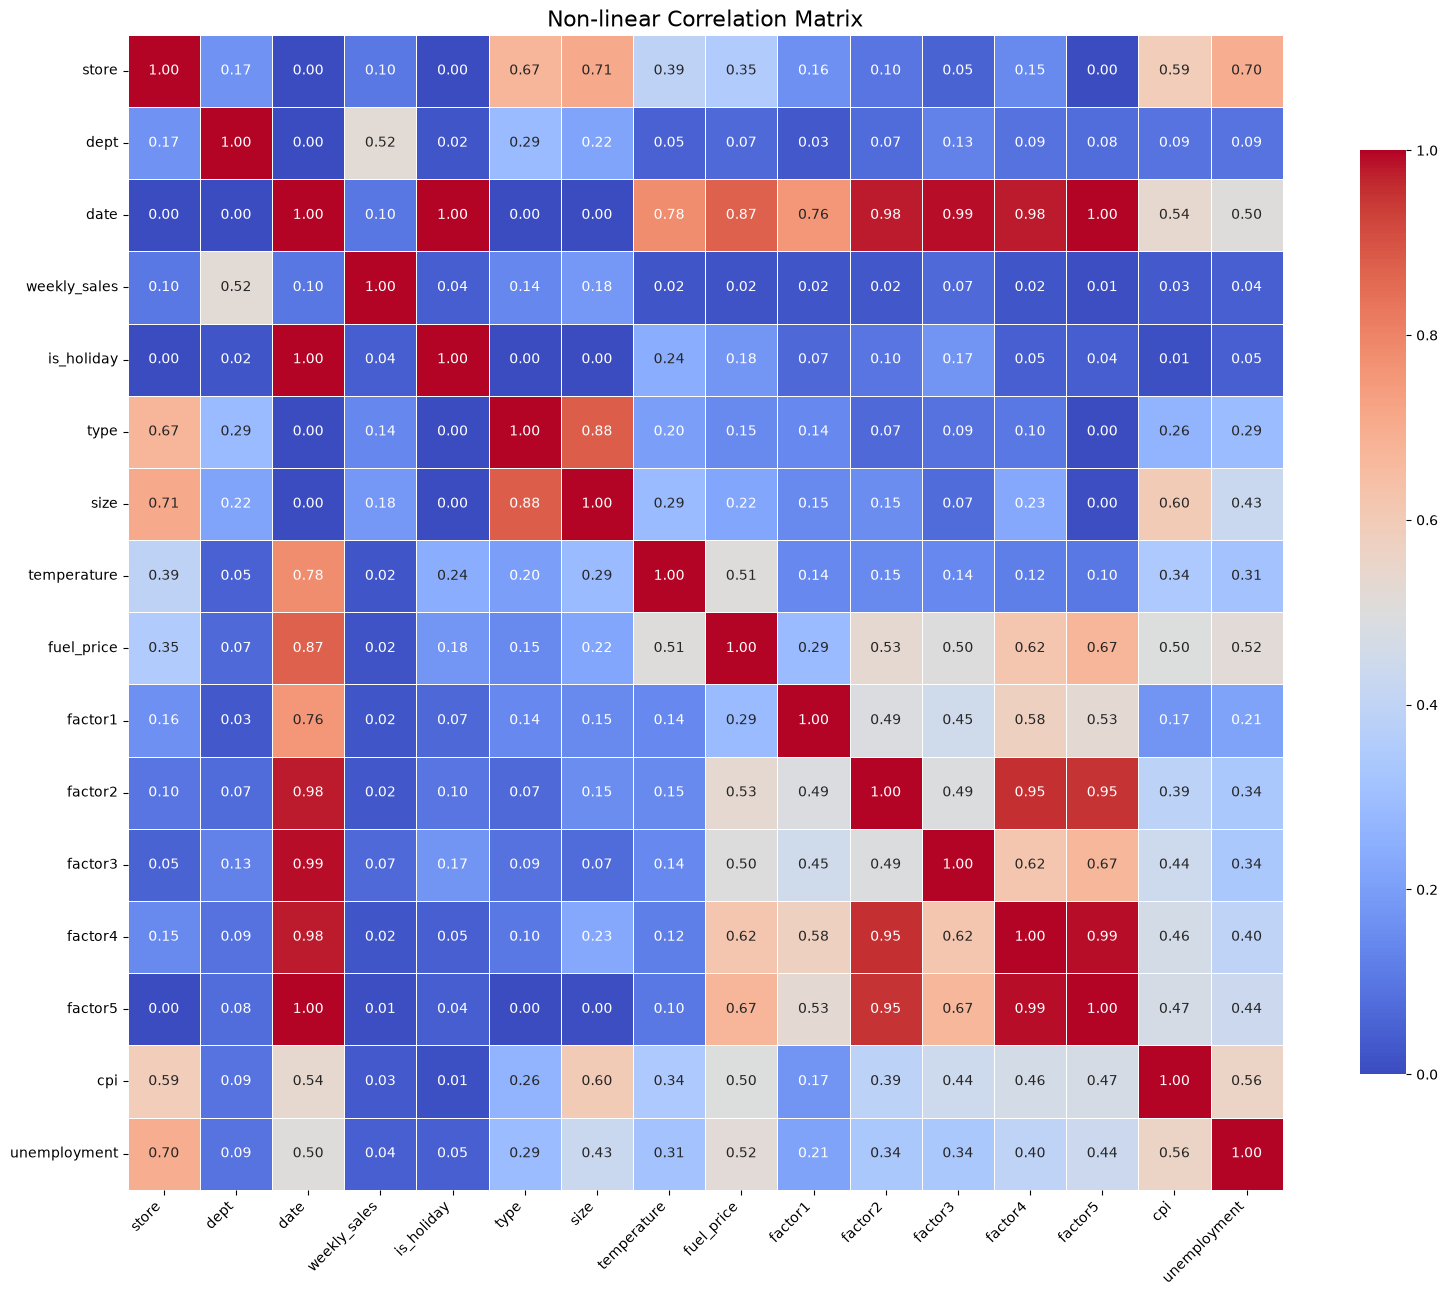

In [27]:
heatmap(df_corr, 'Linear Correlation Matrix')
heatmap(df_phik, 'Non-linear Correlation Matrix')

In [28]:
phik_to_pairs(df_phik).to_frame().head(15)

0
date    is_holiday    1.000000
        factor5       1.000000
        factor3       0.992016
factor4 factor5       0.991420
date    factor4       0.979863
        factor2       0.978503
factor2 factor4       0.954248
        factor5       0.950905
size    type          0.880550
date    fuel_price    0.874038
        temperature   0.778182
        factor1       0.755800
size    store         0.708908
store   unemployment  0.698083
factor5 fuel_price    0.674627

In [29]:
df_phik[TARGET_COL].drop(index=[TARGET_COL]).sort_values(ascending=False).head(15)

dept            0.523140
size            0.180410
type            0.140121
store           0.103643
date            0.097950
factor3         0.067568
unemployment    0.044443
is_holiday      0.041194
cpi             0.033628
factor2         0.023601
factor4         0.023152
factor1         0.022808
temperature     0.019840
fuel_price      0.018260
factor5         0.007767
Name: weekly_sales, dtype: float64

**Вывод по задаче**

Сильнее всего коррелируют с целевой переменной:
1) `dept` (номер отдела) — 0.52. Объёмы отделов сильно различаются, это главный сигнал.
2) `size` (размер даркстора) — 0.18. Крупнее магазин — выше продажи.
3) `type` (тип A/B/C) — 0.14. Связан с размером, отдельного сильного эффекта почти нет.
4) `store` — 0.10. Слабее, чем отдел; частично дублирует `size`/`type`.
5) `date` — 0.10. Сезонность есть, но «сырая» дата даёт слабую связь.


Между собой сильно коррелируют:
- `size` и `type` (0.88), `size` и `store` (0.71) — тип и номер магазина почти следуют из размера;
- `store` и `unemployment` (0.70) — безработица привязана к региону магазина;
- `date` с `is_holiday`, `factor2–5`, ценой бензина и температурой (0.76–1.00) — календарь и промо зависят от времени; часть завышена из‑за высокой кардинальности `date`;
- промо-факторы между собой (`factor2/4/5` ≈ 0.95–0.99)

**Задача:** обработайте аномалии в продажах.

In [30]:
dfs['sales'].describe().T

,count,mean,min,25%,50%,75%,max,std
store,421570.0,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
dept,421570.0,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
date,421570,2024-06-17 08:30:31,2023-02-05 00:00:00,2023-10-08 00:00:00,2024-06-16 00:00:00,2025-02-23 00:00:00,2025-10-26 00:00:00,NaN
weekly_sales,421570.0,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519


In [31]:
print('Количество отрицательных продаж: ', (dfs['sales']['weekly_sales'] < 0).sum())

Количество отрицательных продаж:  1285


Отрицательные weekly_sales — возвраты, когда за неделю возвратов больше, чем продаж. Для закупок отрицательный спрос бессмысленен: заказ поставщику не может отрицательным. Заменим такие значения на ноль

**примечание**
Корректнее было бы обсудить с бизнессом, какой объем закупок считать минимальным. Возможно, наиболее подходящее минимальное значение больше нуля. Так как с бизнессом в данной задаче нам не связаться пример минимальный объем продаж за ноль

In [32]:
# Замена отрицательных продаж на 0
df['weekly_sales'] = df['weekly_sales'].clip(lower=0)

In [33]:
# Проверка на отсутствие отрицательных продаж
assert df['weekly_sales'].min() == 0, 'Отрицательные продажи не заменены на 0!'

**Вывод по задаче**

Вычислили аномалии в данных. Это признак `weekly_sales`, он может принимать отрицательные значения за недели, когда возвратов было больше чем продаж. Для предсказания закупок отрицательные значения не имеют смысла и заменены на ноль

**Задача:** исследуйте аномально высокие продажи.

Найдите записи с очень высокими продажами (например, топ 0.01% или выше 99.99% квантиля). Попробуйте найти закономерности:
- В какое время года они происходят?
- Связаны ли они с праздниками?
- Какие типы дарксторов и отделы демонстрируют пиковые продажи?

Ранее мы разбирали графики продаж по неделям и месяцам. Там мы выяснили, что абслютным рекордсменом по продажам является декабрь. Проверим это наблюдение на примере аномально высоких продаж:

In [34]:
# Аномальные продажи
df_anomaly = df[df['weekly_sales'] > dfs['sales']['weekly_sales'].quantile(0.9999)]

In [35]:
print('Количество аномально высоких продаж:', len(df_anomaly)) 

Количество аномально высоких продаж: 43


In [36]:
df_anomaly['date'].dt.month.value_counts()

date
11    31
12    11
2      1
Name: count, dtype: int64

In [37]:
df_anomaly['is_holiday'].value_counts()

is_holiday
True     31
False    12
Name: count, dtype: int64

In [38]:
df_anomaly['type'].value_counts()

type
A    26
B    17
Name: count, dtype: int64

**Вывод по задаче**

Аномально высокие продажи (43 строки выше 99.99-квантиля) - это пиковый спрос.

Почти все приходятся на конец года: 31 в ноябре, 11 в декабре, одна в феврале. 31 из 43 — праздничные недели (`is_holiday=True`), остальные 12 — соседние предпраздничные. Это совпадает с декабрьскими пиками на графиках.

Рекорды только в дарксторах A (26) и B (17). Тип C в топ не попадает.

Удалять или клипать эти значения не нужно: это повторяющаяся сезонность.

### Шаг 2. Предобработка признаков и feature engineering

**Задача:** реализуйте функцию `create_temporal_features` для извлечения временных признаков из столбца `Date`.

Извлеките из даты:
- Месяц (`month`).
- Квартал (`quarter`).
- Год (`year`).

Эти признаки помогут модели уловить сезонные паттерны.

In [ ]:
def create_temporal_features(df) -> pd.DataFrame:
    df = df.copy()
    
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year

    return df

df = create_temporal_features(df)

In [40]:
assert 'month' in df.columns, 'Месяц не создан!'
assert 'quarter' in df.columns, 'Квартал не создан!'
assert 'year' in df.columns, 'Год не создан!'

**Вывод по задаче**
Функция реализована

**Задача:** cоздайте агрегированные признаки в функции `create_avg_sales_feature` — средние продажи по комбинации «даркстор и отдел».

**Важно: Избегайте утечки данных!**

При создании агрегатов для каждой строки используйте только данные **до** этой даты:
- Для даты 2025-09-08 считайте среднее по данным с начала до 2025-09-07 включительно.
- Для даты 2025-09-15 считайте среднее по данным с начала до 2025-09-14 включительно.

Это критически важно, чтобы модель не использовала информацию из будущего!

In [ ]:
def create_avg_sales_feature(df):
    df = df.copy().sort_values(by='date')

    df['avg_sales_before'] = (
        df.groupby(['store', 'dept'])['weekly_sales']
        .transform(lambda x: x.shift(1).expanding().mean()) # Включаем текущую дату в расчет, так как дата - это конец недели
    )

    return df

df = create_avg_sales_feature(df)

In [42]:
assert 'avg_sales_before' in df.columns, 'Признак средних продаж не создан!'

**Вывод по задаче**
Признак `avg_sales_before` создан, утечка данных недопускается при помощи расширяющегося окна по дате

**Задача:** создайте лаговые признаки в функции `create_lag_features` — продажи 1, 2 и 4 недели назад.

Лаговые признаки позволяют модели учитывать историю продаж:
- `sales_1week_ago` — продажи неделю назад.
- `sales_2week_ago` — продажи 2 недели назад.
- `sales_4week_ago` — продажи 4 недели назад.

Это одни из самых важных признаков для прогнозирования временных рядов!

In [ ]:
def create_lag_features(df):
    df = df.copy().sort_values(by='date')

    df_grouped = df.groupby(['store', 'dept'])

    df['sales_1week_ago'] = df_grouped['weekly_sales'].shift(1)
    df['sales_2week_ago'] = df_grouped['weekly_sales'].shift(2)
    df['sales_4week_ago'] = df_grouped['weekly_sales'].shift(4)
    
    return df

df = create_lag_features(df)

In [44]:
assert 'sales_1week_ago' in df.columns, 'Признак sales_1week_ago не создан!'
assert 'sales_2week_ago' in df.columns, 'Признак sales_2week_ago не создан!'
assert 'sales_4week_ago' in df.columns, 'Признак sales_4week_ago не создан!'

**Вывод по задаче**
Добавлены лаговые признаки продаж

**Задача:** cоздайте признаки скользящего среднего продаж за последние 2 и 4 недели в функции `create_rolling_features`.

Скользящее среднее сглаживает колебания и показывает общий тренд:
- `mean_sales_2week` — среднее продаж за последние 2 недели.
- `mean_sales_4week` — среднее продаж за последние 4 недели.

Эти признаки помогают уловить краткосрочные и среднесрочные тренды.

In [ ]:
def create_rolling_features(df):
    df = df.copy().sort_values(by='date')

    df['mean_sales_2week'] = df.groupby(['store', 'dept'])['weekly_sales'].transform(lambda x: x.shift(1).rolling(window=2).mean())
    df['mean_sales_4week'] = df.groupby(['store', 'dept'])['weekly_sales'].transform(lambda x: x.shift(1).rolling(window=4).mean())

    return df

df = create_rolling_features(df)

In [46]:
assert 'mean_sales_2week' in df.columns, 'Признак mean_sales_2week не создан!'
assert 'mean_sales_4week' in df.columns, 'Признак mean_sales_4week не создан!'

**Вывод по задаче**
Добавлены скользящие признаки продаж

**Задача:** удалите строки с пропусками.

После создания лаговых и агрегированных признаков неизбежно появятся пропуски (особенно для первых недель, где нет истории). Удалите такие строки с помощью `dropna()`.

In [47]:
# Количество пропусков
df.isna().sum().sum()

np.int64(46180)

In [48]:
# Удаление строк с пропусками
df = df.dropna()

# Количество пропусков после удаления
df.isna().sum().sum()

np.int64(0)

**Задача:** закодировать месяц и квартал с помощью sin/cos для лучшего понимания цикличности моделью

In [ ]:
# Функция для кодирования месяца и квартала с помощью sin/cos
def sin_cos_encoder(df):
    df = df.copy()
    
    df['month_sin'] = np.sin(df['month'] * (2 * np.pi / 12))
    df['month_cos'] = np.cos(df['month'] * (2 * np.pi / 12))
    df['quarter_sin'] = np.sin(df['quarter'] * (2 * np.pi / 4))
    df['quarter_cos'] = np.cos(df['quarter'] * (2 * np.pi / 4))

    df = df.drop(columns=['month', 'quarter'])
    return df

In [50]:
df = sin_cos_encoder(df)
df.head()

,store,dept,date,weekly_sales,is_holiday,type,size,temperature,fuel_price,factor1,...,avg_sales_before,sales_1week_ago,sales_2week_ago,sales_4week_ago,mean_sales_2week,mean_sales_4week,month_sin,month_cos,quarter_sin,quarter_cos
13800,20,20,2023-03-05,7077.92,False,A,203742,31.75,2.777,7028.8,...,6871.7375,6528.34,6997.76,8419.85,6763.050,6871.7375,1.0,6.123234e-17,1.0,6.123234e-17
13804,36,97,2023-03-05,7717.86,False,A,39910,51.33,2.574,7028.8,...,7874.2050,7126.54,8226.44,8138.42,7676.490,7874.2050,1.0,6.123234e-17,1.0,6.123234e-17
13798,15,23,2023-03-05,19491.21,False,B,123737,31.79,2.919,7028.8,...,20418.3825,17662.16,21921.62,20584.19,19791.890,20418.3825,1.0,6.123234e-17,1.0,6.123234e-17
13802,33,98,2023-03-05,8955.91,False,A,39690,59.17,2.877,7028.8,...,9279.8875,9427.70,9015.06,8747.47,9221.380,9279.8875,1.0,6.123234e-17,1.0,6.123234e-17
13797,19,71,2023-03-05,9058.12,False,A,203819,32.92,2.919,7028.8,...,9186.8225,7813.54,9471.49,9935.22,8642.515,9186.8225,1.0,6.123234e-17,1.0,6.123234e-17


### Шаг 3. Мониторинг стабильности признаков

**Задача:** разделите данные на обучающую и валидационную выборки **по времени**.

Разделение:
- **Обучение**: февраль 2023 — август 2025.
- **Валидация**: сентябрь 2025 — октябрь 2025.

Такое разделение имитирует реальное применение модели: обучаем на прошлых данных, проверяем на будущих.

In [82]:
# Разделение данных
def split_data(df):
    df = df.sort_values(by='date')

    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]

    X_train = X[X['date'] < '2025-09-01']
    X_val = X[X['date'] >= '2025-09-01']

    y_train = y[X['date'] < '2025-09-01']
    y_val = y[X['date'] >= '2025-09-01']


    X_train = X_train.drop(columns='date')
    X_val = X_val.drop(columns='date')

    return X_train, X_val, y_train, y_val

X_train, X_val, y_train, y_val = split_data(df)

# Количество строк в каждой выборке
print(f"Обучающая выборка: {len(X_train)} строк")
print(f"Валидационная выборка: {len(X_val)} строк")

Обучающая выборка: 384726 строк
Валидационная выборка: 23710 строк


**Вывод по задаче**

Данные разделены на тренировочную и валидационную выборку по дате. 

**Задача:** рассчитайте PSI для всех признаков.

PSI измеряет стабильность распределения признака между обучающей и валидационной выборками:
- **PSI < 0.1** — признак стабилен, можно использовать.
- **0.1 ≤ PSI < 0.2** — умеренный дрейф, требуется внимание.
- **PSI ≥ 0.2** — значительный дрейф, признак нестабилен.

In [83]:
def calculate_psi(expected: pd.Series, actual: pd.Series, bins: int = 10, eps: float = 1e-10) -> float:
    expected = expected.dropna()
    actual = actual.dropna()

    is_numeric = (
        pd.api.types.is_numeric_dtype(expected)
        and pd.api.types.is_numeric_dtype(actual)
        and not pd.api.types.is_bool_dtype(expected)
        and not pd.api.types.is_bool_dtype(actual)
    )

    if is_numeric:
        edges = np.linspace(
            min(expected.min(), actual.min()),
            max(expected.max(), actual.max()),
            bins + 1,
        )
        expected_share = np.histogram(expected, bins=edges)[0] / len(expected)
        actual_share = np.histogram(actual, bins=edges)[0] / len(actual)
    else:
        cats = pd.Index(expected.unique()).union(pd.Index(actual.unique()))
        expected_share = expected.value_counts(normalize=True).reindex(cats, fill_value=0).to_numpy()
        actual_share = actual.value_counts(normalize=True).reindex(cats, fill_value=0).to_numpy()

    expected_bins = np.where(expected_share == 0, eps, expected_share)
    actual_bins = np.where(actual_share == 0, eps, actual_share)

    return ((expected_bins - actual_bins) * np.log(expected_bins / actual_bins)).sum()
    

In [84]:
psi = pd.DataFrame(
    {col: calculate_psi(X_train[col], X_val[col]) for col in X_train.columns},
    index=['PSI']
).T.sort_values(by='PSI', ascending=False)

psi.head()

,PSI
month_cos,18.559033
month_sin,17.313801
year,17.052201
factor5,15.867768
quarter_cos,11.831662


**Вывод по задаче**
Реализована функция для подсчета psi признаков с различными типами данных

**Задача:** интерпретируйте результаты PSI.

Проанализируйте полученные значения PSI:
- Какие признаки стабильны?
- Для каких признаков наблюдается дрейф?

Визуализируйте распределения признаков с высоким PSI на обучении и валидации для лучшего понимания.

In [85]:
psi

,PSI
month_cos,18.559033
month_sin,17.313801
year,17.052201
factor5,15.867768
quarter_cos,11.831662
quarter_sin,11.831662
fuel_price,11.795403
temperature,3.121860
factor3,1.898663
factor4,1.651006


**Вывод по задаче**

**Стабильные (PSI < 0.1)** — оставляем:
- идентификаторы: `store`, `dept`, `type`, `size`;
- история продаж: `avg_sales_before`, лаги, скользящие средние;
- `is_holiday`

**Умеренный дрейф:** `factor2` (0.18) — на границе, можно оставить и проверить по важности модели.

**Сильный дрейф (PSI ≥ 0.2):**
- календарь: `month_*`, `quarter_*` и `year`. В них ожидаемый дрейф, так как в валидационной выборке данные только за 2 месяца 2025 года. Год можем убрать, а месяц и квартал оставить, они отвечат за сезонность 
- внешние/промо: `factor5` (15.9), `fuel_price` (11.8), `temperature` (3.1), `factor3`, `factor4`, `unemployment`, `cpi`, `factor1`. Здесь дрейф реальный — распределения на val уже другие. Эти признаки исключаем.

**Итог для обучения:** опираемся на стабильные признаки с PSI < 0.2 и календарны признаки

**Задача:** Визуализировать распределение признаков с высоким psi.

In [86]:
def plot_psi_feature(col, X_train, X_val, bins=50):
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(X_train[col], bins=bins, stat='density', alpha=0.5, label='train', ax=ax)
    sns.histplot(X_val[col], bins=bins, stat='density', alpha=0.5, label='val', ax=ax)
    ax.set_title(f'{col} — распределение train vs val')
    ax.legend()
    plt.show()

In [87]:
cols_with_high_psi = [
    c for c in psi[psi['PSI'] >= 0.2].index
    if not (c.startswith('month_') or c.startswith('quarter_'))
]

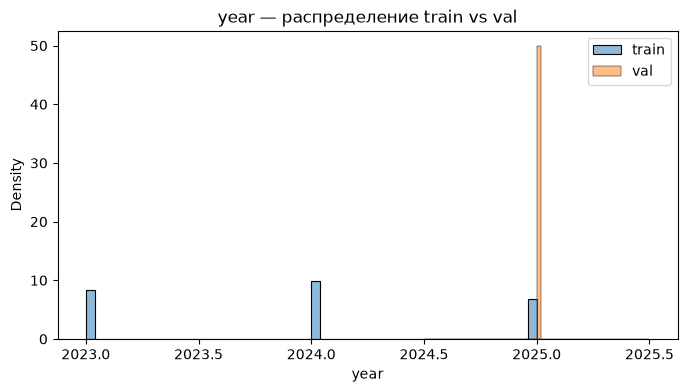

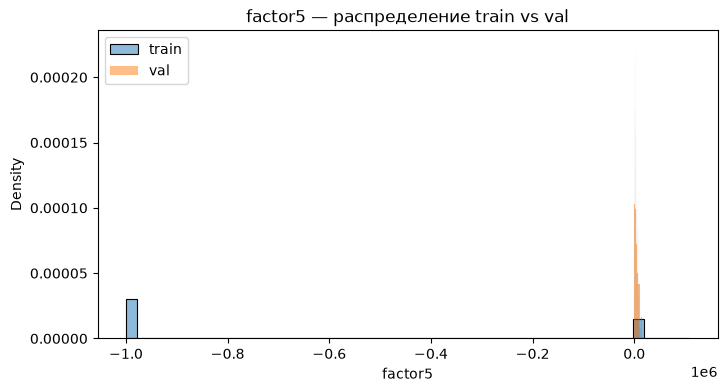

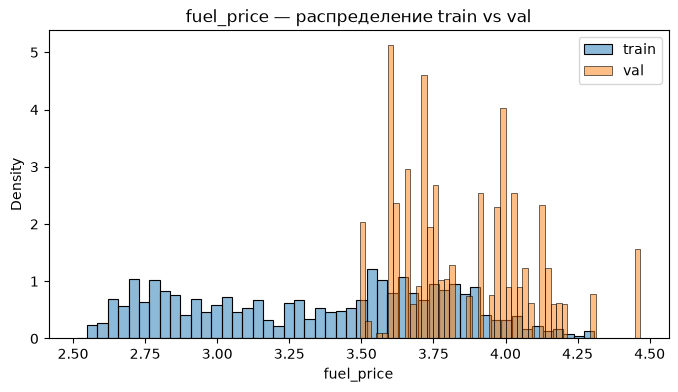

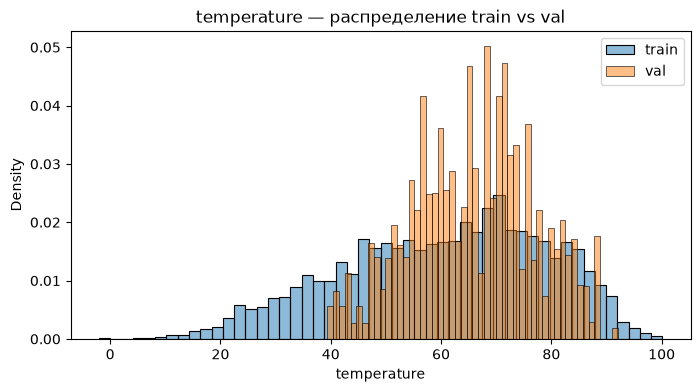

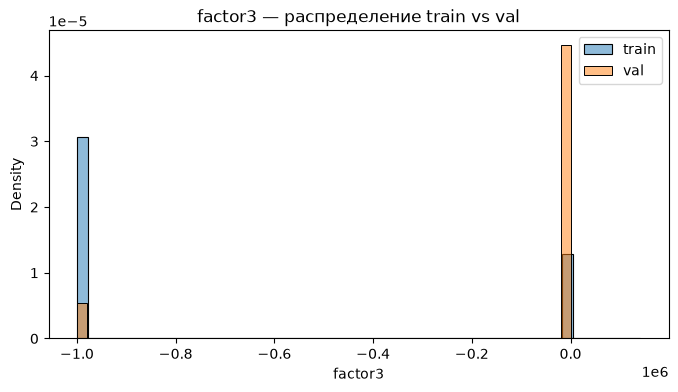

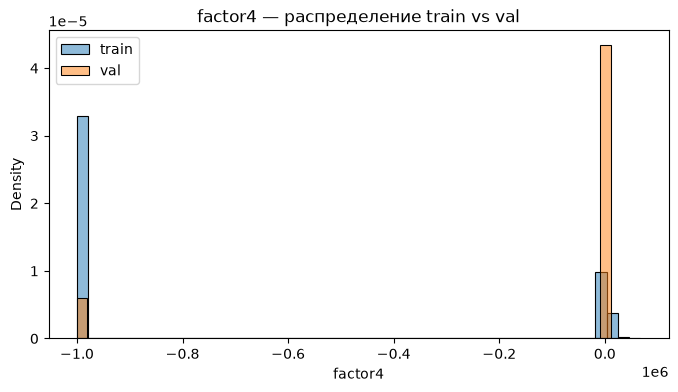

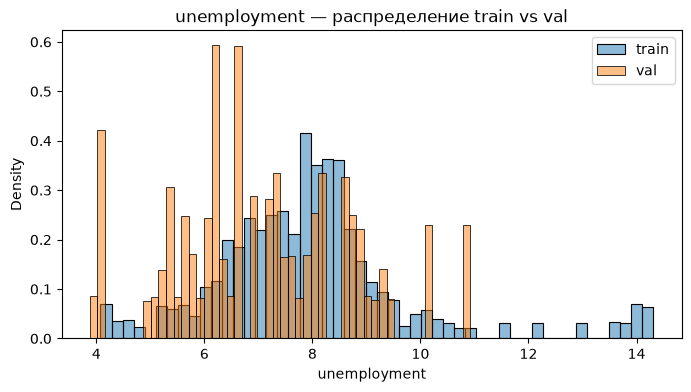

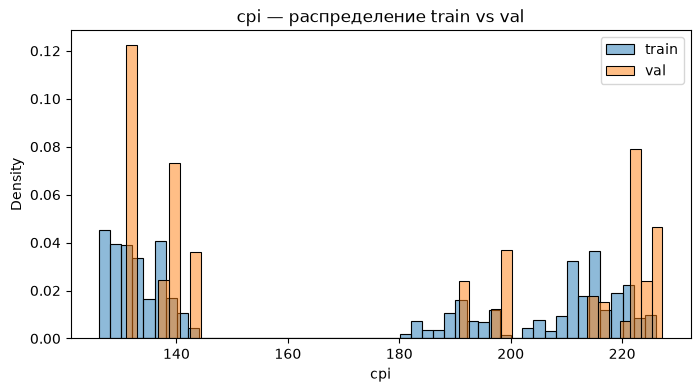

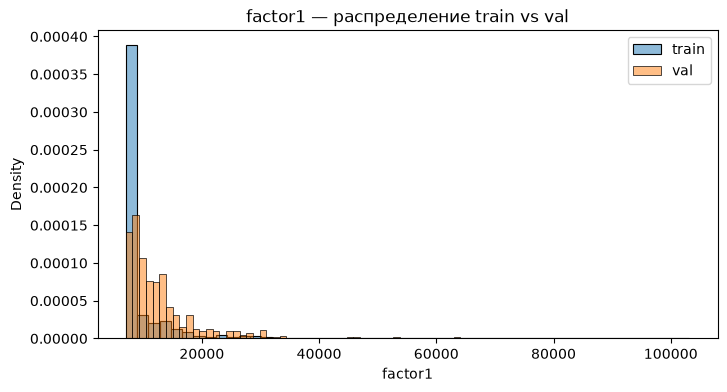

In [88]:
for col in cols_with_high_psi:
    plot_psi_feature(col, X_train, X_val)

**Вывод по задаче**

Графики подтверждают разницу в распределениях признаков с высоким psi между train и val выборками. На val распределение заметно смещено относительно train — это реальный дрейф, их исключаем.

**Задача:** удалите признаки с PSI ≥ 0.2.

Признаки с высоким PSI нестабильны и могут ухудшить качество модели в будущем. Удалите их из обучающей и валидационной выборок.

При этом оставим признаки `month_*` и `quarter_*`

In [89]:
# Удалите все признаки, у которых PSI ≥ 0.2 (кроме `month_*` и `quarter_*`)
X_train = X_train.drop(columns=cols_with_high_psi)
X_val = X_val.drop(columns=cols_with_high_psi)

X_train.head()


,store,dept,is_holiday,type,size,factor2,avg_sales_before,sales_1week_ago,sales_2week_ago,sales_4week_ago,mean_sales_2week,mean_sales_4week,month_sin,month_cos,quarter_sin,quarter_cos
13800,20,20,False,A,203742,-1000265.76,6871.7375,6528.34,6997.76,8419.85,6763.050,6871.7375,1.0,6.123234e-17,1.0,6.123234e-17
11839,23,27,False,B,114533,-1000265.76,4005.3925,3659.48,4151.96,4285.21,3905.720,4005.3925,1.0,6.123234e-17,1.0,6.123234e-17
11846,3,6,False,B,37392,-1000265.76,2461.0525,2289.72,2767.05,2181.93,2528.385,2461.0525,1.0,6.123234e-17,1.0,6.123234e-17
11845,43,96,False,C,41062,-1000265.76,21560.0550,19819.59,20805.37,20269.89,20312.480,21560.0550,1.0,6.123234e-17,1.0,6.123234e-17
11844,11,59,False,A,207499,-1000265.76,997.8300,945.00,907.34,1093.30,926.170,997.8300,1.0,6.123234e-17,1.0,6.123234e-17


In [100]:
X_train['store'].nunique()

45

**Вывод по задаче**
Подготовлен набор признаков с достаточно низким показателем PSI (<0.2)

### Шаг 4. Обучение модели CatBoost

**Задача:** обучите модель CatBoost.

Используйте **обучающую** выборку.

In [90]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 384726 entries, 13800 to 397820
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   store             384726 non-null  int64  
 1   dept              384726 non-null  int64  
 2   is_holiday        384726 non-null  bool   
 3   type              384726 non-null  str    
 4   size              384726 non-null  int64  
 5   factor2           384726 non-null  float64
 6   avg_sales_before  384726 non-null  float64
 7   sales_1week_ago   384726 non-null  float64
 8   sales_2week_ago   384726 non-null  float64
 9   sales_4week_ago   384726 non-null  float64
 10  mean_sales_2week  384726 non-null  float64
 11  mean_sales_4week  384726 non-null  float64
 12  month_sin         384726 non-null  float64
 13  month_cos         384726 non-null  float64
 14  quarter_sin       384726 non-null  float64
 15  quarter_cos       384726 non-null  float64
dtypes: bool(1), float64(11), int64(3

In [101]:
from catboost import CatBoostRegressor

CAT_FEATURES = ['store', 'dept', 'is_holiday', 'type']

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    cat_features=CAT_FEATURES,
    early_stopping_rounds=50,
    verbose=False
)

In [102]:
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
)

CatBoostRegressor(cat_features=['store', 'dept', 'is_holiday', 'type'], depth=6, early_stopping_rounds=50, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=1703, verbose=False)

**Задача:** оцените качество модели на валидационной выборке.

Используйте метрики:
- **MAE**.
- **RMSE**.
- **R²**.

In [103]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred = model.predict(X_val)

metrics_df = pd.DataFrame({
    "MAE": [mean_absolute_error(y_val, y_pred)],
    "RMSE": [root_mean_squared_error(y_val, y_pred)],
    "R2": [r2_score(y_val, y_pred)]
})

metrics_df

,MAE,RMSE,R2
0,1450.781999,3050.534079,0.980405


**Вывод по задаче**

На валидации модель показывает сильное качество: MAE ~= 403р, RMSE ~= 1 271р, R2 ~= 0.997. Средняя ошибка мала относительно типичных недельных продаж (тысячи–десятки тысяч р), а почти единичный R2 говорит, что модель хорошо объясняет дисперсию таргета — во многом за счёт лагов и истории отдела.


**Задача:** оцените качество модели на тренировочной выборке и сравните с валидационной для выявления переобучения

In [104]:
y_pred_train = model.predict(X_train)

metrics_df_train = pd.DataFrame({
    "MAE": [mean_absolute_error(y_train, y_pred_train)],
    "RMSE": [root_mean_squared_error(y_train, y_pred_train)],
    "R2": [r2_score(y_train, y_pred_train)]
}, index=['train'])

metrics_df_train.loc['val'] = metrics_df.loc[0]

metrics_df_train

,MAE,RMSE,R2
train,1856.937490,5177.485521,0.948331
val,1450.781999,3050.534079,0.980405


**Вывод по задаче**

При сравнении train и val признаков переобучения нет: на валидации ошибки не выше, а по всем метрикам даже ниже, чем на обучении. Такая картина означает, что модель не «запомнила» train, а переносится на отложенный период не хуже. Небольшое преимущество val может быть связано с тем, что train длиннее и разнообразнее по сезонам и режимам продаж, а val — короткий и относительно однородный срез. Для задачи это приемлемо: модель можно использовать дальше, но качество на новых периодах стоит периодически перепроверять.


**Задача:** проанализируйте важность признаков.

Она показывает, какие признаки наиболее важны для модели:
- Проверьте, нет ли в топе признаков, которые могут приводить к утечке данных.
- Посмотрите, какие признаки действительно влияют на продажи.


In [105]:
# Оценка важности признаков с помощью CatBoost.feature_importances_
pd.DataFrame(
    model.feature_importances_, 
    index=X_train.columns,
    columns=['importance']
).sort_values(by='importance', ascending=False)

,importance
sales_1week_ago,34.807335
mean_sales_4week,15.533637
mean_sales_2week,15.515270
sales_4week_ago,10.768583
avg_sales_before,6.157642
sales_2week_ago,5.323761
is_holiday,4.382232
month_cos,3.180584
dept,1.626137
month_sin,1.033881


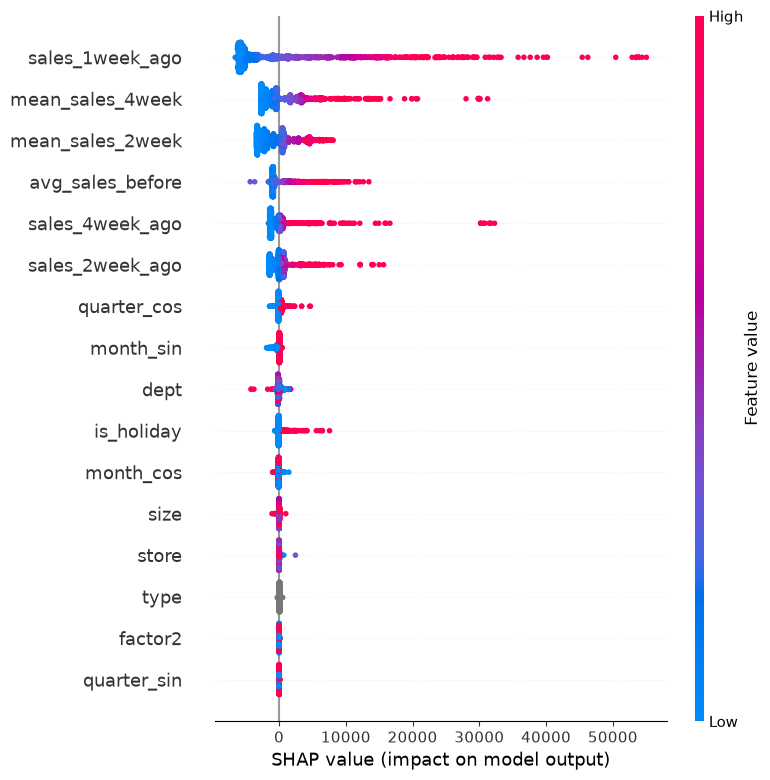

In [106]:
# Оценка важности признаков с помощью shap.TreeExplainer
explainer = shap.TreeExplainer(model)

# subsample — полный X_val для SHAP может считаться долго
X_shap = X_val.sample(n=min(2000, len(X_val)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)


**Вывод по задаче**

Утечки в топе нет: лидируют `mean_sales_2week` (~73%), `sales_1week_ago` (~13%) и остальные лаги/скользящие/`avg_sales_before`. Все они считаются только по прошлым неделям той же пары store–dept, без текущего `weekly_sales`.

На продажи реально влияет короткая история самого отдела: модель почти целиком опирается на недавние продажи. Дальше по важности — `is_holiday` и `dept`, слабее `factor2`, `size`, `store`, `type`. Тип и номер даркстора почти не нужны отдельно: уровень уже зашит в средних и лагах.

**Задача:** сохраните обученную модель в S3.

Модель нужно сохранить для дальнейшего использования в batch-инференсе. Код уже реализован, необходимо просто его запустить.

**Важно:** не указывайте секреты явно в ноутбуке, используйте переменные окружения.

In [107]:
import io
import pickle
import boto3
import os

# Создаём клиент для подключения к S3
s3_client = boto3.client(
    's3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id=os.getenv('S3_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv('S3_SECRET_KEY'),
    region_name='ru-central1'
)

# Сохраняем модель в буфер
filebuffer = io.BytesIO()
pickle.dump(model, filebuffer)
filebuffer.seek(0)

# Загружаем в S3
s3_client.upload_fileobj(
    Fileobj=filebuffer,
    Bucket=os.getenv('S3_BUCKET'),
    Key='catboost_model.pkl'
)

print(f"Модель успешно загружена в {os.getenv('S3_BUCKET')}/catboost_model.pkl")

Модель успешно загружена в s3-ds-20260811-10b3f4c2d5/catboost_model.pkl
